In [28]:
from pathlib import Path
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt

folder = Path(".")

combined = defaultdict(list)

for csv_file in sorted(folder.glob("*.csv")):
    df = pd.read_csv(csv_file)

    for column in df.columns:
        combined[column].extend(df[column].tolist())

NumInactive = combined["NumInactive"]
NumActive = combined["NumActive"]
NumCells = combined["NumCells"]
FractionActive = combined["FractionActive"]
FractionInactive = combined["FractionInactive"]
Name = combined["Name"]
Parameters = combined["Parameters"]

In [29]:
groups = {
    "CASPR_3d_0.5μl": ["B - 02", "B - 03", "B - 04", "B - 05"],
    "CASPR_3d_1μl": ["C - 02", "C - 03", "C - 04", "C - 05"],
    "CASPR_3d_5μl": ["D - 02", "D - 03", "D - 04", "D - 05"],
    "CASPR_7d_0.5μl": ["E - 02", "E - 03", "E - 04", "E - 05"],
    "CASPR_7d_1μl": ["F - 02", "F - 03", "F - 04", "F - 05"],
    "CASPR_7d_5μl": ["G - 02", "G - 03", "G - 04", "G - 05"],

    "GFP_3d_0.5μl": ["B - 07", "B - 08", "B - 09", "B - 10"],
    "GFP_3d_1μl": ["C - 07", "C - 08", "C - 09", "C - 10"],
    "GFP_3d_5μl": ["D - 07", "D - 08", "D - 09", "D - 10"],
    "GFP_7d_0.5μl": ["E - 07", "E - 08", "E - 09", "E - 10"],
    "GFP_7d_1μl": ["F - 07", "F - 08", "F - 09", "F - 10"],
    "GFP_7d_5μl": ["G - 07", "G - 08", "G - 09", "G - 10"]
}

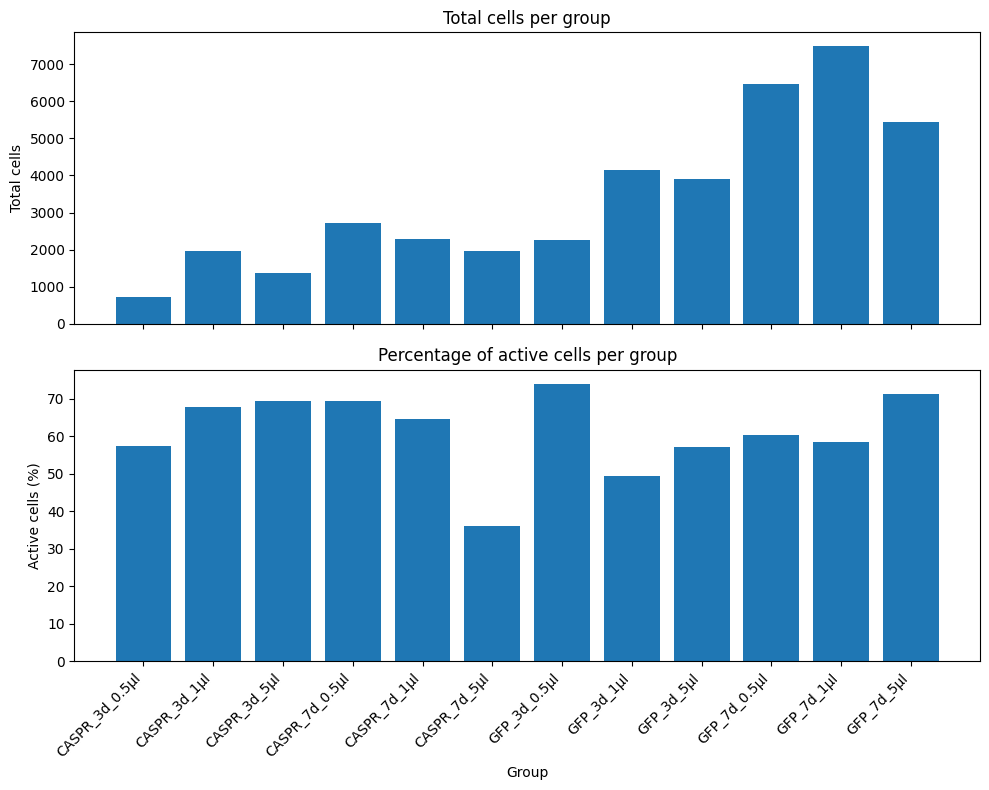

In [41]:
# Make dictionaries to store total cells and active cells per group
group_total_cells = defaultdict(int)
group_active_cells = defaultdict(int)

thresh = 12

for name, num_cells, num_active in zip(Name, NumCells, NumActive):

    for group_name, prefixes in groups.items():

        if any(name.startswith(prefix) for prefix in prefixes):
            if num_cells >= thresh:
                group_total_cells[group_name] += num_cells
                group_active_cells[group_name] += num_active
            break


# Calculate percentage active cells per group
group_percent_active = {}

for group_name in groups.keys():
    total_cells = group_total_cells[group_name]
    active_cells = group_active_cells[group_name]

    if total_cells > 0:
        group_percent_active[group_name] = active_cells / total_cells * 100
    else:
        group_percent_active[group_name] = 0


# Print values
# for group_name, percent in group_percent_active.items():
#     print(group_name, percent)


# -------------------------------
# Multi-plot: total cells + percent active
# -------------------------------

group_names = list(groups.keys())

total_cells = [
    group_total_cells[group_name]
    for group_name in group_names
]

percent_active = [
    group_percent_active[group_name]
    for group_name in group_names
]

x = range(len(group_names))

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(10, 8),
    sharex=True
)

# Plot 1: total cells per group
axes[0].bar(x, total_cells)
axes[0].set_ylabel("Total cells")
axes[0].set_title("Total cells per group")

# Plot 2: percentage active cells per group
axes[1].bar(x, percent_active)
axes[1].set_ylabel("Active cells (%)")
axes[1].set_xlabel("Group")
axes[1].set_title("Percentage of active cells per group")

# X-axis labels
axes[1].set_xticks(x)
axes[1].set_xticklabels(group_names, rotation=45, ha="right")

plt.tight_layout()
plt.show()